# EDA Notebook

Notebook này đã sẵn sàng để phân tích dữ liệu và trực quan hóa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# Shape & data types
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("\n--- Data Types ---")
print(df.dtypes.value_counts())

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(f"\nColumns with missing values: {len(missing_df)}")
print(missing_df.head(20))

Rows: 307,511 | Columns: 122

--- Data Types ---
float64    65
int64      41
object     16
Name: count, dtype: int64

Columns with missing values: 67
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865        69.87
COMMONAREA_MODE                  214865        69.87
COMMONAREA_AVG                   214865        69.87
NONLIVINGAPARTMENTS_MODE         213514        69.43
NONLIVINGAPARTMENTS_MEDI         213514        69.43
NONLIVINGAPARTMENTS_AVG          213514        69.43
FONDKAPREMONT_MODE               210295        68.39
LIVINGAPARTMENTS_AVG             210199        68.35
LIVINGAPARTMENTS_MEDI            210199        68.35
LIVINGAPARTMENTS_MODE            210199        68.35
FLOORSMIN_MEDI                   208642        67.85
FLOORSMIN_MODE                   208642        67.85
FLOORSMIN_AVG                    208642        67.85
YEARS_BUILD_MODE                 204488        66.50
YEARS_BUILD_MEDI                 204488        66.50
YE

=== TARGET Distribution ===
Trả được nợ (0): 282,686 (91.9%)
Vỡ nợ      (1): 24,825 (8.1%)


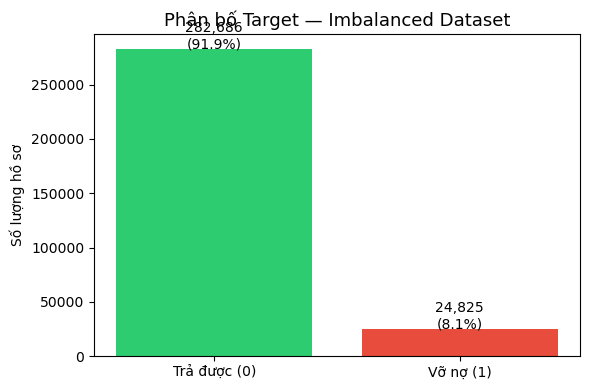

In [3]:
# Tỷ lệ vỡ nợ tổng thể
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("=== TARGET Distribution ===")
print(f"Trả được nợ (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"Vỡ nợ      (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Trả được (0)', 'Vỡ nợ (1)'], target_counts, color=['#2ecc71', '#e74c3c'])
ax.set_title('Phân bố Target — Imbalanced Dataset', fontsize=13)
ax.set_ylabel('Số lượng hồ sơ')
for i, v in enumerate(target_counts):
    ax.text(i, v + 1000, f'{v:,}\n({target_pct[i]:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

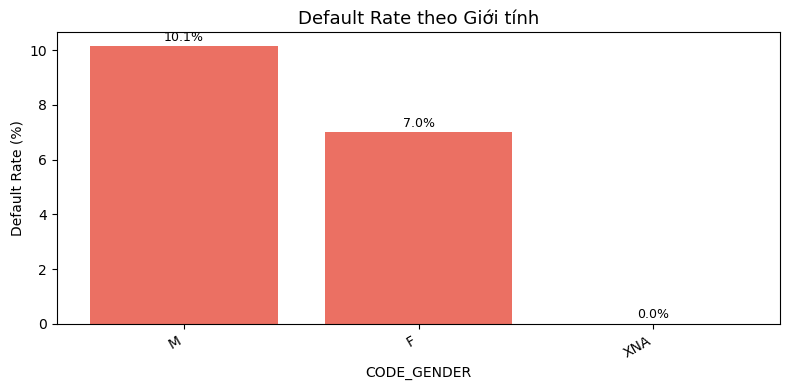

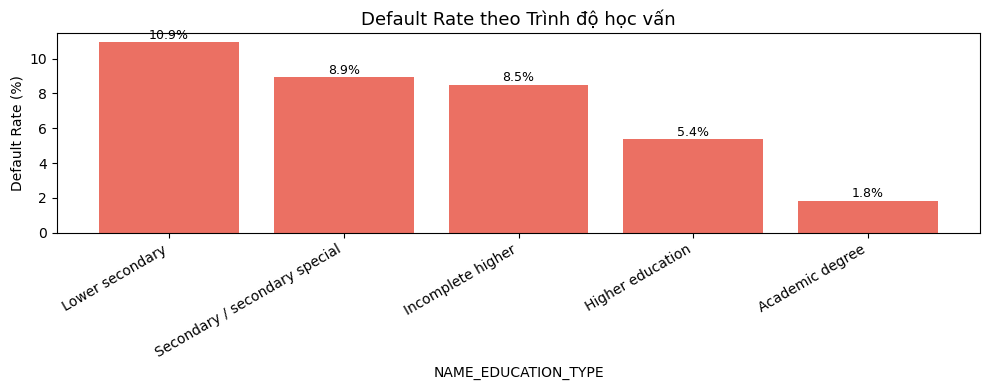

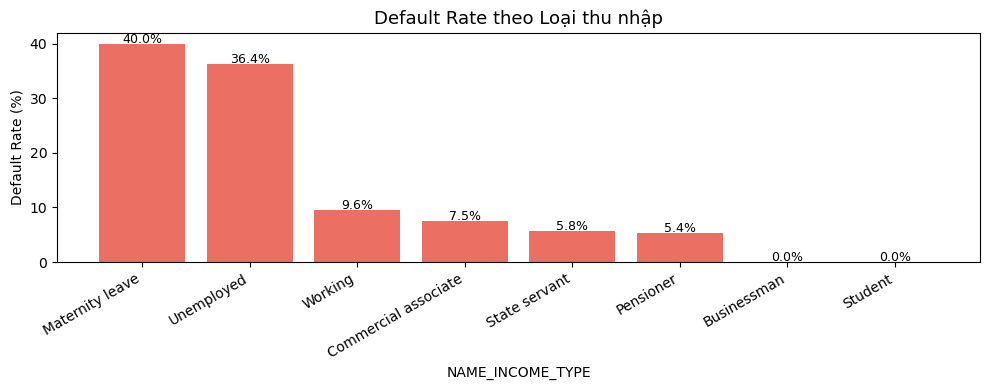

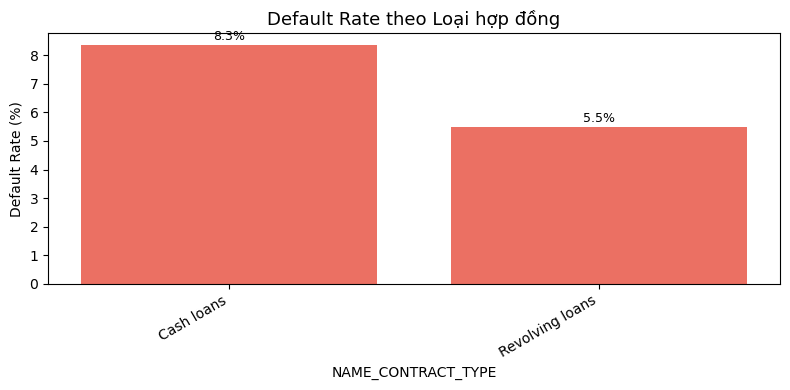

NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64

In [4]:
# Hàm tiện ích
def default_rate_plot(col, title, figsize=(8, 4)):
    rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(rate.index, rate.values, color='#e74c3c', alpha=0.8)
    ax.set_title(f'Default Rate theo {title}', fontsize=13)
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel(col)
    plt.xticks(rotation=30, ha='right')
    for bar, val in zip(bars, rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    return rate

# Chạy từng segment
default_rate_plot('CODE_GENDER', 'Giới tính')
default_rate_plot('NAME_EDUCATION_TYPE', 'Trình độ học vấn', figsize=(10, 4))
default_rate_plot('NAME_INCOME_TYPE', 'Loại thu nhập', figsize=(10, 4))
default_rate_plot('NAME_CONTRACT_TYPE', 'Loại hợp đồng')

C:\Users\trant\AppData\Local\Temp\ipykernel_24820\85530959.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False) * 100


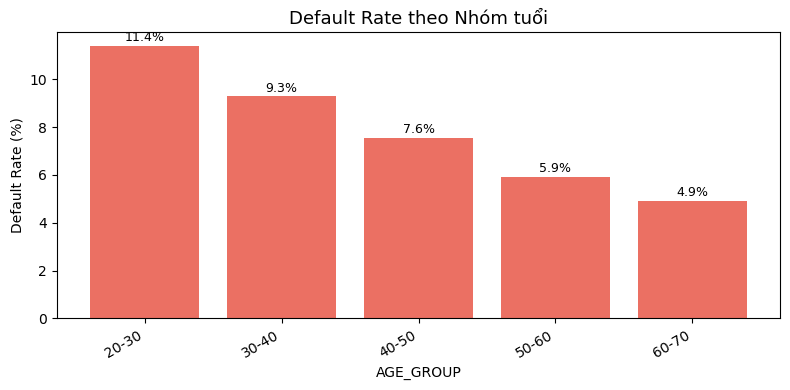

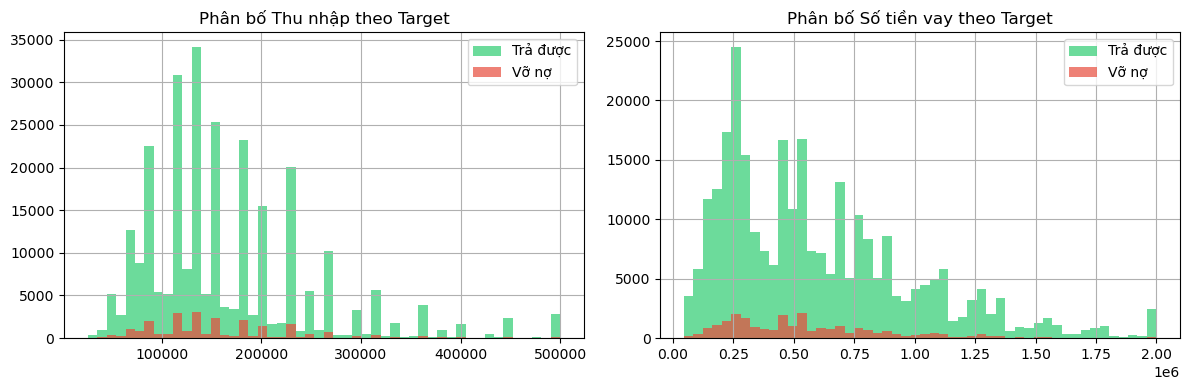

In [5]:
# Tạo age từ DAYS_BIRTH
df['AGE_YEARS'] = (df['DAYS_BIRTH'] / -365).astype(int)
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70],
                          labels=['20-30', '30-40', '40-50', '50-60', '60-70'])

default_rate_plot('AGE_GROUP', 'Nhóm tuổi')

# Income vs Default
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[df['TARGET']==0]['AMT_INCOME_TOTAL'].clip(upper=500000).hist(
    bins=50, ax=axes[0], color='#2ecc71', alpha=0.7, label='Trả được')
df[df['TARGET']==1]['AMT_INCOME_TOTAL'].clip(upper=500000).hist(
    bins=50, ax=axes[0], color='#e74c3c', alpha=0.7, label='Vỡ nợ')
axes[0].set_title('Phân bố Thu nhập theo Target')
axes[0].legend()

# Credit Amount
df[df['TARGET']==0]['AMT_CREDIT'].clip(upper=2000000).hist(
    bins=50, ax=axes[1], color='#2ecc71', alpha=0.7, label='Trả được')
df[df['TARGET']==1]['AMT_CREDIT'].clip(upper=2000000).hist(
    bins=50, ax=axes[1], color='#e74c3c', alpha=0.7, label='Vỡ nợ')
axes[1].set_title('Phân bố Số tiền vay theo Target')
axes[1].legend()
plt.tight_layout()
plt.show()